### Notebook 5: Grouping Events

In the last notebook, we averaged the signals from all LFEs.  But we may want to sort the events into groups and just average within those groups.  Then we can compare the stacks obtained from various groups.  

This notebook gives one approach to grouping: events that occur early or late in a slow slip event. Later, after calculating relative moments, we will also group events by magnitude. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os,sys
import LFEAnalysis as lfeanalysis

### 1. Initialize and read detection info

In [5]:
# as usual, we need to initialize an analysis object
fnum = 1
lf=lfeanalysis.lfeanalyse(fnum=fnum,region='Guerrero',catalog='Frank2014',data_directory="/home/earthquakes1/homes/Julia/LFEAnalysis/DATA")

# and we need the LFE times
lf.read_detection_info_frank2014()

In [6]:
# note that we now have the times of all LFEs in this family
print(lf.tms)
print(lf.tms.shape)

[UTCDateTime(2005, 1, 22, 20, 10, 37, 900000)
 UTCDateTime(2005, 1, 24, 5, 57, 18, 700000)
 UTCDateTime(2005, 1, 26, 2, 26, 16, 600000) ...
 UTCDateTime(2007, 4, 15, 3, 48, 5, 800000)
 UTCDateTime(2007, 4, 15, 3, 48, 48, 300000)
 UTCDateTime(2007, 4, 15, 6, 26, 48, 600000)]
(1159,)


In [7]:
# and the times of all LFEs, including all families
print(lf.atms)
print(lf.atms.shape)

[UTCDateTime(2005, 1, 15, 0, 4, 8, 800000)
 UTCDateTime(2005, 1, 15, 0, 6, 34, 500000)
 UTCDateTime(2005, 1, 15, 0, 9, 36, 700000) ...
 UTCDateTime(2007, 4, 15, 23, 47, 47, 700000)
 UTCDateTime(2007, 4, 15, 23, 48, 38, 400000)
 UTCDateTime(2007, 4, 15, 23, 51, 28, 700000)]
(1837126,)


### 2. Note the large slow slip events



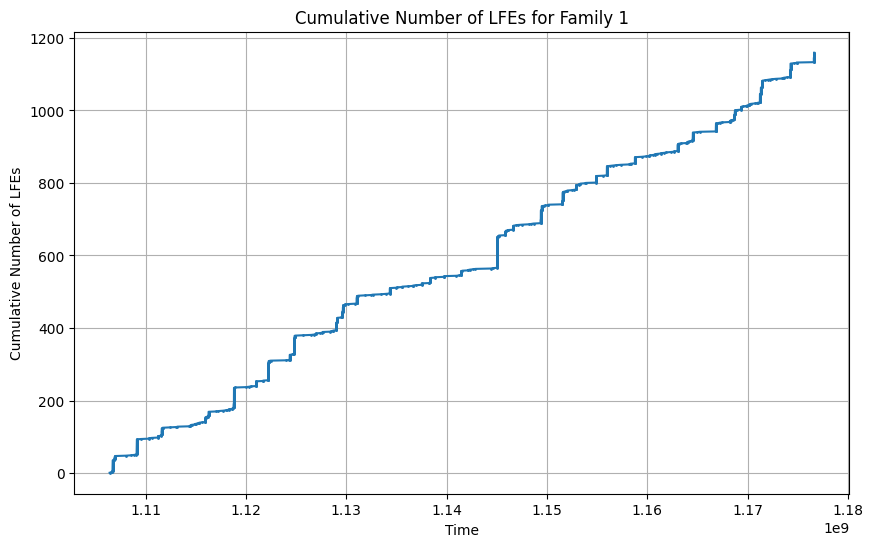

In [8]:
# plot of cumulative events for this family
plt.figure(figsize=(10, 6))
plt.plot(lf.tms, np.arange(1, len(lf.tms) + 1), marker='o', markersize=1, linestyle='-')
plt.title(f'Cumulative Number of LFEs for Family {fnum}')
plt.xlabel('Time')
plt.ylabel('Cumulative Number of LFEs')
plt.grid()

### 3. Group LFEs within a slow slip event

We may wish to identify LFEs that occur early in a slow slip event vs later in a slow slip event---at least within a family.

To do so, we first determine a family "start time" for each SSE. 
We identify bursts at each family with an interevent time threshold. We start a burst where the interevent time drops below a threshold, end it when it goes above a threhold, and discard bursts with fewer than 15 events. 

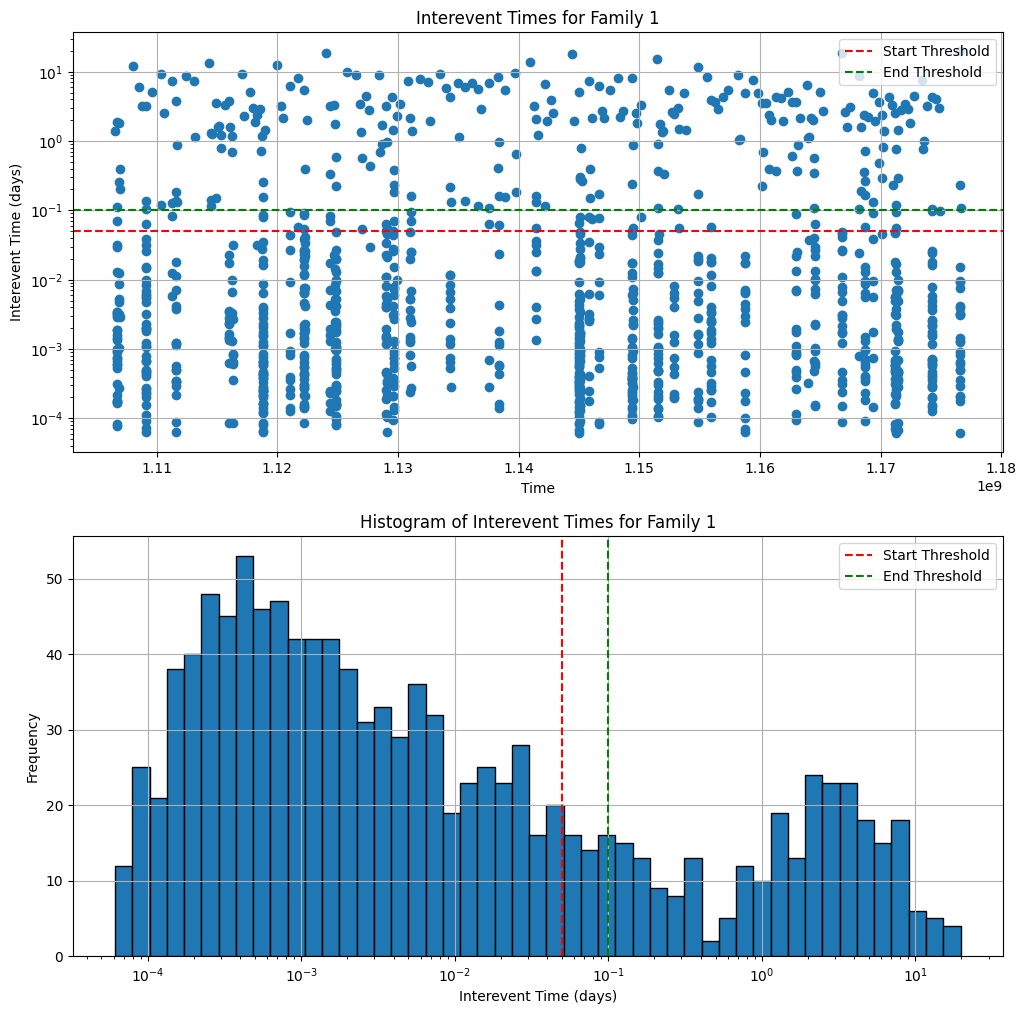

In [9]:
# plots of interevent time - both histogram and the catalogue time 
fig, axs = plt.subplots(2, 1, figsize=(12, 12))

startthreshold = 0.05  # days
endthreshold = 0.1  # days

# Plot time series of interevent times
interevent_times_days = np.diff(lf.tms) / (24 * 3600)  # Convert seconds to days
axs[0].scatter(lf.tms[1:], interevent_times_days, marker='o', linestyle='-')
axs[0].axhline(y=startthreshold, color='r', linestyle='--', label='Start Threshold')
axs[0].axhline(y=endthreshold, color='g', linestyle='--', label='End Threshold')
axs[0].legend()
axs[0].set_title(f'Interevent Times for Family {fnum}')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Interevent Time (days)')
axs[0].set_yscale('log', base=10)
axs[0].grid()

# Plot interevent time histogram
bins = np.logspace(
np.log10(interevent_times_days.min()),
np.log10(interevent_times_days.max()),
50)
axs[1].hist(interevent_times_days, bins=bins, edgecolor='black')
axs[1].axvline(x=startthreshold, color='r', linestyle='--', label='Start Threshold')
axs[1].axvline(x=endthreshold, color='g', linestyle='--', label='End Threshold')
axs[1].legend()
axs[1].set_title(f'Histogram of Interevent Times for Family {fnum}')
axs[1].set_xlabel('Interevent Time (days)')
axs[1].set_ylabel('Frequency')
axs[1].set_xscale('log', base=10)
axs[1].grid()

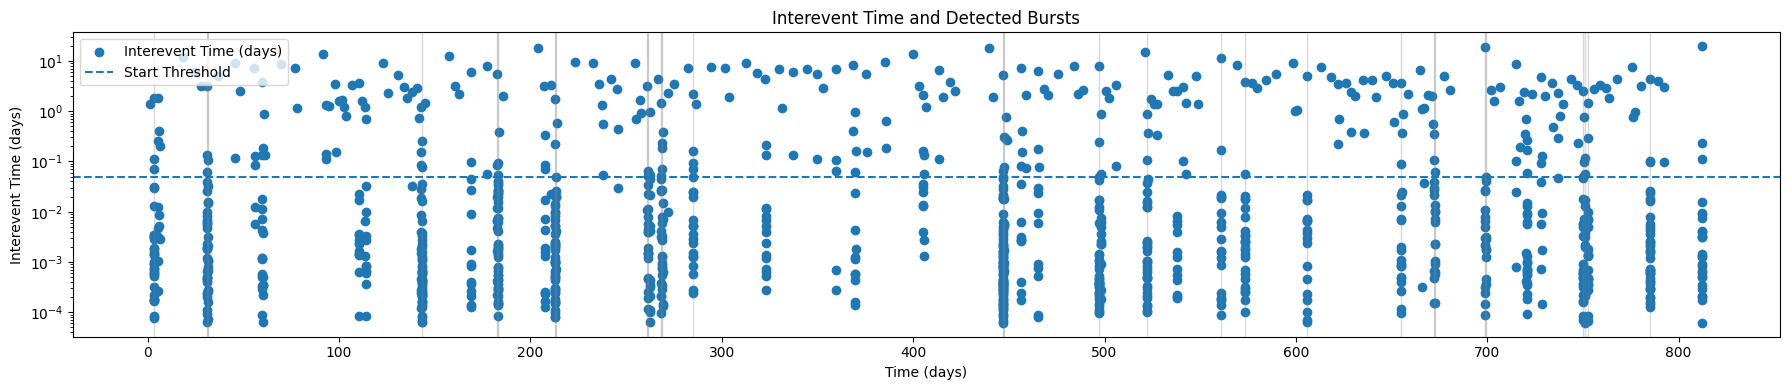

Number of bursts detected: 21


In [12]:
lf.detect_lfe_bursts_interevent(start_threshold=startthreshold, end_threshold=endthreshold, dmin = 15)
lf.plot_lfe_bursts_interevent()

print(f"Number of bursts detected: {len(lf.start_times)}")

Then we group the events into early and late groups by dividing the population. If there is an odd number, the extra event goes in the late group. There are also functions for other grouping schemes. 

In [ ]:
# Split bursts into early and late groups using one of the below methods:

lf.split_events_by_detections()                            # defines middle by number of events  
#lf.split_events_by_time()                                 # defines middle by time in burst 
#lf.split_events_by_interevent(threshold=0.05)             # defines middle as first time interevent time exceeds threshold 
#lf.split_events_by_rate()                                 # defines middle as first time rate drops below threshold 

In [ ]:
# we now have a dictionary 
print('The groups are ',list(lf.groups.keys()))

# here there are two groups: 'early' and 'late'
# the integers listed are the indices of the events in each group, 
# so the times of the first 10 LFEs in the early group are
print('The indices of the first 10 LFEs in the early group are\n',lf.groups['early'][0:10])
print('\nThe times of the first 10 LFEs in the early group are\n',lf.tms[lf.groups['early'][0:10]])

The groups are  ['early', 'late']
The indices of the first 10 LFEs in the early group are
 [ 8  9 10 11 12 13 14 15 16 17]

The times of the first 10 LFEs in the early group are
 [UTCDateTime(2005, 1, 26, 6, 59, 41, 600000)
 UTCDateTime(2005, 1, 26, 7, 1, 1, 900000)
 UTCDateTime(2005, 1, 26, 7, 1, 8, 500000)
 UTCDateTime(2005, 1, 26, 7, 3, 14, 500000)
 UTCDateTime(2005, 1, 26, 7, 4, 7, 300000)
 UTCDateTime(2005, 1, 26, 7, 4, 14, 500000)
 UTCDateTime(2005, 1, 26, 7, 5, 32, 100000)
 UTCDateTime(2005, 1, 26, 7, 7, 48, 800000)
 UTCDateTime(2005, 1, 26, 7, 8, 46, 700000)
 UTCDateTime(2005, 1, 26, 7, 9, 5, 400000)]
